In [1]:
import pandas as pd
best_backend_df = pd.read_csv("./final_data/best_backend_df.csv")
estimate_runtime_df = pd.read_csv("./final_data/estimate_runtime_df.csv")
print("Loaded CSVs from disk.")

from sklearn.preprocessing import OneHotEncoder

def preprocess_df(df):
	categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
	numeric_cols = df.select_dtypes(exclude=["object"]).columns.tolist()

	# Version-safe OneHotEncoder
	try:
		ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)  # sklearn >=1.2
	except TypeError:
		ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)        # sklearn <1.2

	if categorical_cols:
		encoded_array = ohe.fit_transform(df[categorical_cols])
		encoded_cols = ohe.get_feature_names_out(categorical_cols)
		encoded_df = pd.DataFrame(encoded_array, columns=encoded_cols, index=df.index)
		processed_df = pd.concat([df[numeric_cols], encoded_df], axis=1)
	else:
		processed_df = df[numeric_cols].copy()

	return processed_df

best_backend_df_processed = preprocess_df(best_backend_df)
estimate_runtime_df_processed = preprocess_df(estimate_runtime_df)

print("best_backend_df_processed shape:", best_backend_df_processed.shape)
print("estimate_runtime_df_processed shape:", estimate_runtime_df_processed.shape)

Loaded CSVs from disk.
best_backend_df_processed shape: (215, 86)
estimate_runtime_df_processed shape: (3300, 423)


/tmp/ipykernel_3224289/2677519658.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
/tmp/ipykernel_3224289/2677519658.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migr

## 2. Colors & Matplotlib styles

Defines a colorblind-friendly palette if `colors` is not already defined. Uses **matplotlib only**.

In [ ]:
import matplotlib
import matplotlib.pyplot as plt
from pathlib import Path

# ── Paper-quality output config ──
# Target: IEEE single-column (3.5 in) and 2-column (7.16 in) widths.
# Vector PDF, embedded fonts (TrueType, type-42), tight bbox.
IMG_DIR = Path("/lustre/orion/gen008/proj-shared/qhpc/srikar/qfw_related/meta_backend_paper/meta_backend_qfw/images")
IMG_DIR.mkdir(parents=True, exist_ok=True)

COL1_W = 3.5    # IEEE single-column width (in)
COL2_W = 7.16   # IEEE double-column width (in)

matplotlib.rcParams.update({
    "pdf.fonttype": 42,        # TrueType — LaTeX-friendly, no Type-3 issues
    "ps.fonttype": 42,
    "font.family": "serif",
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
    "axes.grid": False,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

def save_fig(name, fig=None):
    """Save the current (or given) figure as PDF into the paper images dir."""
    if fig is None:
        fig = plt.gcf()
    out = IMG_DIR / f"{name}.pdf"
    fig.savefig(out)
    print(f"  saved → {out}")
    return out

# Colorblind-safe palette
colors = [
    "#4E79A7", "#F28E2B", "#E15759", "#76B7B2",
    "#59A14F", "#EDC948", "#B07AA1", "#FF9DA7",
    "#9C755F", "#BAB0AC",
]

# Per-paper sizes (smaller fonts → kept consistent for all save_fig outputs)
TITLE_FONTSIZE = 10
LABEL_FONTSIZE = 9
TICK_FONTSIZE = 8
GRID_ALPHA = 0.3

print(f"Figures will be saved to: {IMG_DIR}")

## 3. Circuit features selection

We prefer an explicit feature list; if some are missing, we auto-include numeric columns that look like circuit descriptors (including those with `gate_` prefix).

In [3]:
import numpy as np
import pandas as pd

# Build circuit_features for the processed runtime DF
all_cols = estimate_runtime_df_processed.columns.tolist()

# Start from explicit list but keep only those present
circuit_features = [c for c in ["n_qubits", "depth", "width", "n_clbits", "n_ops", "n_gates", "n_parameters", "n_connected_components", "n_measure_ops", "single_qubit_gates", "two_qubit_gates", "three_qubit_gates", "four_qubit_gates", "num_separable_circuits", "num_tensor_factors", "num_serial_layers", "qc_width_total", "num_registers", "num_cregs", "num_ancillas", "idle_wires", "global_phase", "dag_size_ops", "dag_edge_count", "longest_path_len", "num_control_flow_ops", "num_barriers", "num_distinct_twoq_pairs", "touch_min", "touch_max", "touch_avg", "clifford_count", "nonclifford_count", "measure_fraction", "total_gate_params", "avg_gate_params", "std_gate_params", "min_gate_params", "max_gate_params", "num_controlled_gates", "num_unitary_factors", "dag_duration", "qc_duration", "gate_barrier", "gate_ccx", "gate_cp", "gate_cu", "gate_cx", "gate_cz", "gate_h", "gate_measure", "gate_p", "gate_rx", "gate_ry", "gate_rz", "gate_s", "gate_swap", "gate_u2"] if c in all_cols]

# Auto-include numeric columns that look like circuit descriptors
auto_candidates = [
	c for c in all_cols
	if (c.startswith("gate_") or c in [
		"n_qubits","depth","width","n_ops","n_gates","n_parameters","n_connected_components",
		"n_measure_ops","single_qubit_gates","two_qubit_gates","three_qubit_gates","four_qubit_gates",
		"num_separable_circuits","num_tensor_factors","num_serial_layers","qc_width_total",
		"num_registers","num_cregs","num_ancillas","idle_wires","global_phase","dag_size_ops",
		"dag_edge_count","longest_path_len","num_control_flow_ops","num_barriers",
		"num_distinct_twoq_pairs","touch_min","touch_max","touch_avg","clifford_count",
		"nonclifford_count","measure_fraction","total_gate_params","avg_gate_params","std_gate_params",
		"min_gate_params","max_gate_params","num_controlled_gates","num_unitary_factors",
		"dag_duration","qc_duration"
	])
]

# Merge and deduplicate
circuit_features = sorted(set(circuit_features) | set(auto_candidates))

print("Number of circuit_features selected:", len(circuit_features))
print("First 20 circuit_features:", circuit_features[:20])

Number of circuit_features selected: 58
First 20 circuit_features: ['avg_gate_params', 'clifford_count', 'dag_duration', 'dag_edge_count', 'dag_size_ops', 'depth', 'four_qubit_gates', 'gate_barrier', 'gate_ccx', 'gate_cp', 'gate_cu', 'gate_cx', 'gate_cz', 'gate_h', 'gate_measure', 'gate_p', 'gate_rx', 'gate_ry', 'gate_rz', 'gate_s']


## 4. Correlation among circuit features

We compute an absolute correlation matrix and list all pairs above a chosen threshold.

Highly correlated pairs (>|0.95|): 174 found
dag_size_ops             <-> num_serial_layers        : 1.000
gate_barrier             <-> num_barriers             : 1.000
gate_barrier             <-> num_registers            : 1.000
gate_ccx                 <-> three_qubit_gates        : 1.000
gate_measure             <-> n_clbits                 : 1.000
gate_measure             <-> n_measure_ops            : 1.000
gate_measure             <-> n_qubits                 : 1.000
gate_measure             <-> qc_width_total           : 1.000
gate_measure             <-> width                    : 1.000
n_clbits                 <-> n_measure_ops            : 1.000
n_clbits                 <-> n_qubits                 : 1.000
n_clbits                 <-> qc_width_total           : 1.000
n_clbits                 <-> width                    : 1.000
n_gates                  <-> n_ops                    : 1.000
n_measure_ops            <-> n_qubits                 : 1.000
n_measure_ops            

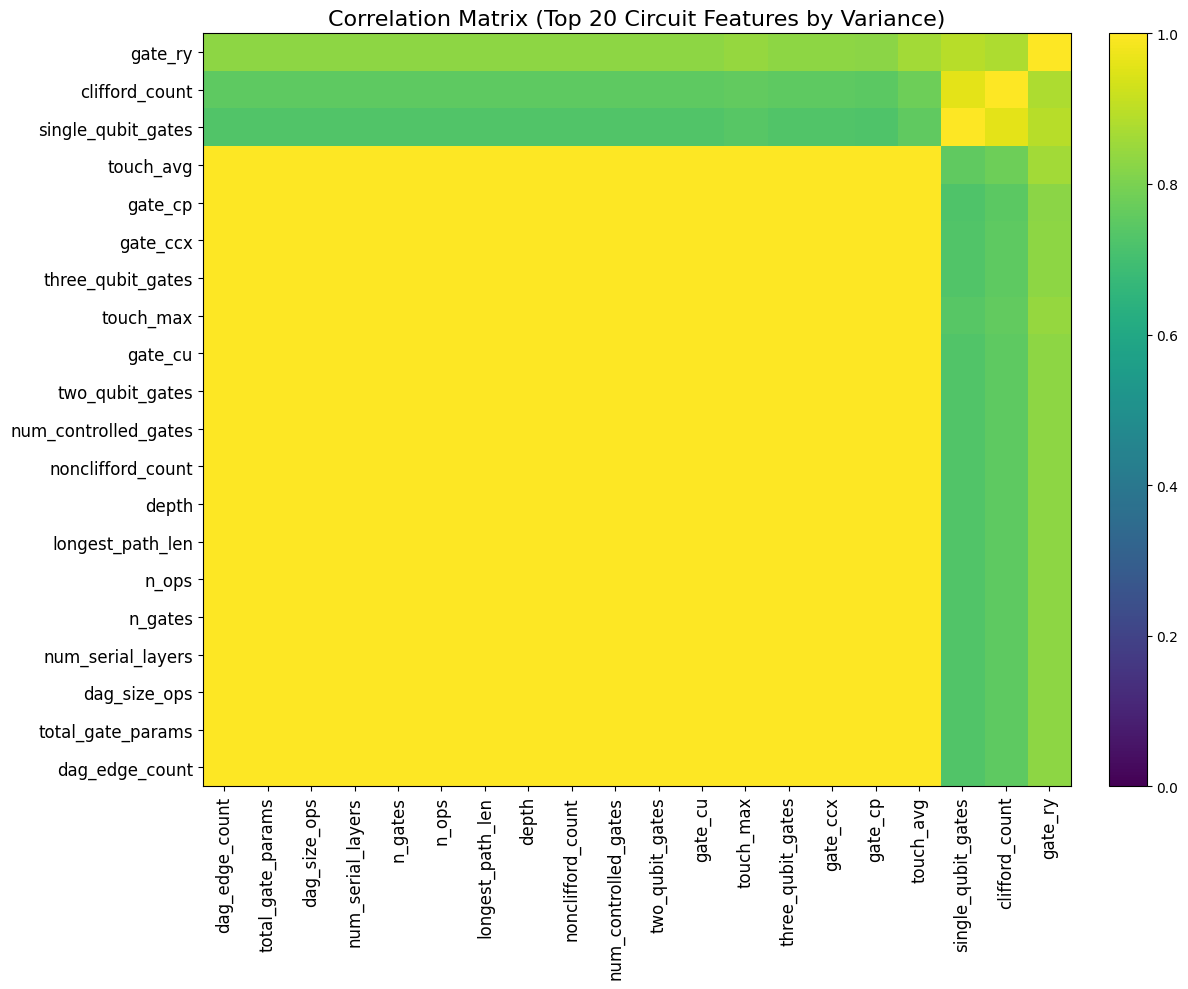

In [ ]:
import numpy as np

# X matrix for circuit-only
X_circuit = estimate_runtime_df_processed[circuit_features].copy()

# Correlation matrix (absolute)
corr_matrix = X_circuit.corr().abs()

# List highly correlated pairs (global)
threshold = 0.95
pairs = []
cols = corr_matrix.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        c = corr_matrix.iloc[i, j]
        if c > threshold:
            pairs.append((cols[i], cols[j], float(c)))

pairs_sorted = sorted(pairs, key=lambda x: -x[2])
print(f"Highly correlated pairs (>|{threshold:.2f}|): {len(pairs_sorted)} found")
for a, b, c in pairs_sorted[:20]:
    print(f"  {a:24s} <-> {b:24s} : {c:.3f}")
if len(pairs_sorted) > 20:
    print(f"  ... and {len(pairs_sorted) - 20} more")

# ── Paper figure: top-N most-variant features correlation heatmap ──
TOP_N = 20
var_rank = X_circuit.var().sort_values(ascending=False)
chosen = var_rank.index[:min(TOP_N, len(var_rank))].tolist()
sub_corr = corr_matrix.loc[chosen, chosen]

fig, ax = plt.subplots(figsize=(COL2_W, COL2_W * 0.85))
im = ax.imshow(sub_corr.values, vmin=0, vmax=1, origin="lower",
               aspect="auto", cmap="viridis")
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
cbar.set_label("|Pearson r|", fontsize=LABEL_FONTSIZE)
ax.set_xticks(range(len(chosen)))
ax.set_xticklabels(chosen, rotation=75, ha="right", fontsize=TICK_FONTSIZE)
ax.set_yticks(range(len(chosen)))
ax.set_yticklabels(chosen, fontsize=TICK_FONTSIZE)
ax.set_title(f"Circuit-feature correlation (top {len(chosen)} by variance)",
             fontsize=TITLE_FONTSIZE)
plt.tight_layout()
save_fig("circuit_feature_correlation")
plt.show()

## 5. Reduced feature set

We drop one feature from each highly correlated pair (threshold = 0.95) to reduce redundancy.

In [6]:
to_drop = set()
seen = set()

# Greedy drop: if (a,b) are highly correlated, drop b if neither has been dropped/kept before
for a,b,c in pairs_sorted:
	if a not in to_drop and b not in to_drop:
		to_drop.add(b)

reduced_features = [f for f in circuit_features if f not in to_drop]

print("Original features:", len(circuit_features))
print("Reduced features:", len(reduced_features))
print("Dropped features (first 20):", list(to_drop)[:20])

Original features: 58
Reduced features: 29
Dropped features (first 20): ['n_clbits', 'std_gate_params', 'touch_avg', 'gate_cp', 'n_gates', 'gate_barrier', 'num_registers', 'touch_max', 'gate_u2', 'n_ops', 'num_barriers', 'single_qubit_gates', 'num_serial_layers', 'gate_cu', 'three_qubit_gates', 'width', 'max_gate_params', 'nonclifford_count', 'n_measure_ops', 'longest_path_len']


## 6. Feature Importance (circuit-only, reduced set)

RandomForestRegressor on the **reduced circuit feature set** to understand which circuit characteristics most influence runtime.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import numpy as np

# Target: prefer mean_ms (paper) — fall back to runtime_ms for older CSVs
target_col = "mean_ms" if "mean_ms" in estimate_runtime_df.columns else "runtime_ms"
mask = estimate_runtime_df[target_col].notna()
y = estimate_runtime_df.loc[mask, target_col].values
X = estimate_runtime_df_processed.loc[mask, reduced_features].values

# Impute NaN circuit features with median (cloud rows lack some metadata)
X = SimpleImputer(strategy="median").fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
top_k = min(15, len(reduced_features))

fig, ax = plt.subplots(figsize=(COL1_W, COL1_W * 0.95))
ax.barh(range(top_k), importances[indices[:top_k]][::-1],
        color=colors[0], edgecolor="black", linewidth=0.4, alpha=0.85)
ax.set_yticks(range(top_k))
ax.set_yticklabels([reduced_features[i] for i in indices[:top_k]][::-1],
                   fontsize=TICK_FONTSIZE)
ax.set_xlabel("Gini importance", fontsize=LABEL_FONTSIZE)
ax.set_title(f"Top-{top_k} circuit features for runtime", fontsize=TITLE_FONTSIZE)
ax.grid(True, axis="x", alpha=GRID_ALPHA)
plt.tight_layout()
save_fig("circuit_only_feature_importance")
plt.show()

KeyError: 'mean_ms'

## 7. Problem 1 — Estimate Runtime (Regression)

Predict `mean_ms` using **circuit metadata + backend / device / run_mode + n_nodes + n_processes**.
We exclude runtime statistics (`mean_ms`, `std_ms`) from features and use a one-hot pipeline.

MAE : 22086.180 ms
RMSE: 76314.400 ms
R^2 : 0.529


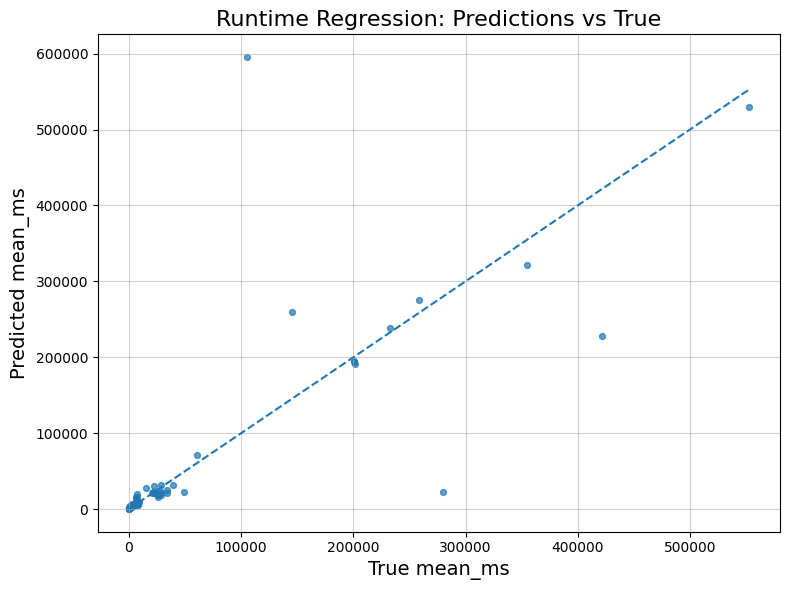

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import numpy as np

# Target: prefer mean_ms; fall back to runtime_ms for per-sample CSVs
target_col = "mean_ms" if "mean_ms" in estimate_runtime_df.columns else "runtime_ms"

reg_df = estimate_runtime_df.dropna(subset=[target_col]).copy()
drop_cols = [c for c in [target_col, "std_ms"] if c in reg_df.columns]
X_full = reg_df.drop(columns=drop_cols)
y_full = reg_df[target_col].values

categorical_cols = X_full.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X_full.select_dtypes(exclude=["object"]).columns.tolist()

try:
    ohe_full = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe_full = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer([
    ("categorical", ohe_full, categorical_cols),
    ("numeric", SimpleImputer(strategy="median"), numeric_cols),
])

reg_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(n_estimators=400, random_state=42, n_jobs=-1)),
])

X_tr, X_te, y_tr, y_te = train_test_split(X_full, y_full, test_size=0.2, random_state=42)
reg_model.fit(X_tr, y_tr)
y_hat = reg_model.predict(X_te)

mae = mean_absolute_error(y_te, y_hat)
rmse = float(np.sqrt(((y_te - y_hat) ** 2).mean()))
r2 = r2_score(y_te, y_hat)
print(f"MAE : {mae:.2f} ms")
print(f"RMSE: {rmse:.2f} ms")
print(f"R^2 : {r2:.3f}")

# ── Paper figure: predicted vs true (log–log to handle wide dynamic range) ──
fig, ax = plt.subplots(figsize=(COL1_W, COL1_W))
ax.scatter(y_te, y_hat, s=8, alpha=0.5, color=colors[0],
           edgecolor="black", linewidth=0.2)
lo = max(min(y_te.min(), y_hat.min()), 1e-3)
hi = max(y_te.max(), y_hat.max())
ax.plot([lo, hi], [lo, hi], "--", color="gray", linewidth=0.8)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("True runtime (ms)", fontsize=LABEL_FONTSIZE)
ax.set_ylabel("Predicted runtime (ms)", fontsize=LABEL_FONTSIZE)
ax.set_title(f"Runtime regression  (R² = {r2:.2f})", fontsize=TITLE_FONTSIZE)
ax.grid(True, which="both", alpha=GRID_ALPHA)
plt.tight_layout()
save_fig("runtime_regression_scatter")
plt.show()

## 8. Problem 2 — Best Backend (Classification)

Predict `best_backend` from **circuit metadata + execution parameters** in `best_backend_df`.
We exclude `best_runtime` from features.

Accuracy: 0.875
              precision    recall  f1-score   support

        ionq       0.00      0.00      0.00         1
      nwqsim       0.86      1.00      0.92        12
   qiskitaer       1.00      0.67      0.80         3

    accuracy                           0.88        16
   macro avg       0.62      0.56      0.57        16
weighted avg       0.83      0.88      0.84        16



/lustre/orion/gen008/proj-shared/qhpc/srikar/qfw_related/results_analysis/jupyter_notebooks/.venv/lib64/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/lustre/orion/gen008/proj-shared/qhpc/srikar/qfw_related/results_analysis/jupyter_notebooks/.venv/lib64/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/lustre/orion/gen008/proj-shared/qhpc/srikar/qfw_related/results_analysis/jupyter_notebooks/.venv/lib64/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedM

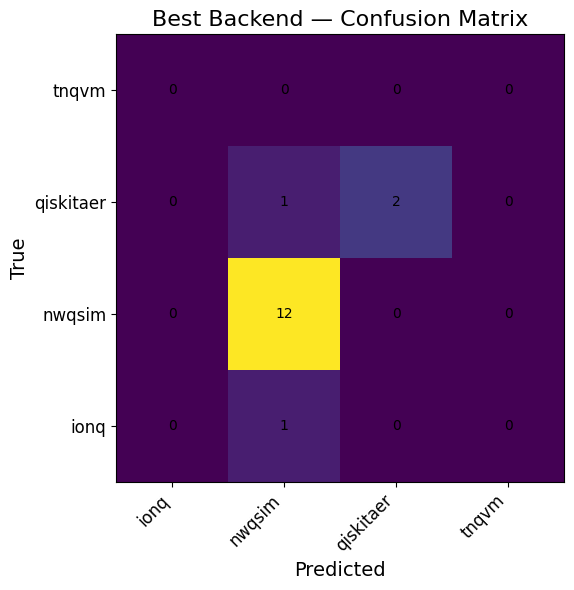

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Drop label-leaking columns
X_cls = best_backend_df.drop(
    columns=[c for c in ["best_backend", "best_runtime", "sub_backend"]
             if c in best_backend_df.columns]
)
y_cls = best_backend_df["best_backend"]

categorical_cols_cls = X_cls.select_dtypes(include=["object"]).columns.tolist()
numeric_cols_cls = X_cls.select_dtypes(exclude=["object"]).columns.tolist()

try:
    ohe_cls = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe_cls = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor_cls = ColumnTransformer([
    ("categorical", ohe_cls, categorical_cols_cls),
    ("numeric", SimpleImputer(strategy="median"), numeric_cols_cls),
])

clf = Pipeline([
    ("preprocessor", preprocessor_cls),
    ("model", RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)),
])

min_class = y_cls.value_counts().min()
stratify = y_cls if min_class >= 2 else None
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=stratify
)

clf.fit(Xc_tr, yc_tr)
yc_hat = clf.predict(Xc_te)

acc = accuracy_score(yc_te, yc_hat)
print(f"Accuracy: {acc:.3f}")
print(classification_report(yc_te, yc_hat, zero_division=0))

# ── Paper figure: confusion matrix ──
labels = sorted(y_cls.unique().tolist())
cm = confusion_matrix(yc_te, yc_hat, labels=labels)

fig, ax = plt.subplots(figsize=(COL1_W, COL1_W * 0.95))
im = ax.imshow(cm, cmap="Blues")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=TICK_FONTSIZE)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=TICK_FONTSIZE)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                fontsize=TICK_FONTSIZE,
                color="white" if cm[i, j] > cm.max() / 2 else "black")
ax.set_xlabel("Predicted", fontsize=LABEL_FONTSIZE)
ax.set_ylabel("True", fontsize=LABEL_FONTSIZE)
ax.set_title(f"Backend classification  (acc = {acc:.2f})", fontsize=TITLE_FONTSIZE)
plt.tight_layout()
save_fig("best_backend_confusion_matrix")
plt.show()

## 9. Additional Visualizations

- PCA on the **reduced circuit feature set** to inspect variance structure.
- Correlation matrix of the **reduced set** (matplotlib-only heatmap).

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import numpy as np

# Standardise reduced circuit features, impute NaNs (cloud rows), then PCA.
X_red = estimate_runtime_df_processed[reduced_features].values
X_red = SimpleImputer(strategy="median").fit_transform(X_red)
X_red = StandardScaler().fit_transform(X_red)

pca = PCA(n_components=min(10, X_red.shape[1]))
X_pca = pca.fit_transform(X_red)

cum = np.cumsum(pca.explained_variance_ratio_)
print("Cumulative explained variance per component:")
for k, v in enumerate(cum, 1):
    print(f"  PC{k:2d}: {v*100:5.2f}%")

# ── Paper figure: cumulative explained variance ──
fig, ax = plt.subplots(figsize=(COL1_W, COL1_W * 0.7))
ax.plot(range(1, len(cum) + 1), cum * 100, marker="o",
        color=colors[0], linewidth=1.2, markersize=4)
ax.axhline(99, ls="--", color="gray", linewidth=0.7)
ax.text(1.05, 99.4, "99 %", fontsize=TICK_FONTSIZE, color="gray")
ax.set_xlabel("Number of PCA components", fontsize=LABEL_FONTSIZE)
ax.set_ylabel("Cumulative explained variance (%)", fontsize=LABEL_FONTSIZE)
ax.set_title("PCA on reduced circuit feature set", fontsize=TITLE_FONTSIZE)
ax.set_ylim(0, 102)
ax.grid(True, alpha=GRID_ALPHA)
plt.tight_layout()
save_fig("pca_explained_variance")
plt.show()

# ── Paper figure: PC1 vs PC2 scatter, coloured by backend ──
if pca.n_components_ >= 2 and "backend" in estimate_runtime_df.columns:
    fig, ax = plt.subplots(figsize=(COL1_W, COL1_W * 0.95))
    backends = estimate_runtime_df["backend"].fillna("?").to_numpy()
    for i, bk in enumerate(sorted(set(backends))):
        m = backends == bk
        ax.scatter(X_pca[m, 0], X_pca[m, 1], s=6, alpha=0.6,
                   color=colors[i % len(colors)], label=bk,
                   edgecolor="none")
    ax.set_xlabel("PC1", fontsize=LABEL_FONTSIZE)
    ax.set_ylabel("PC2", fontsize=LABEL_FONTSIZE)
    ax.set_title("PCA scatter (coloured by backend)", fontsize=TITLE_FONTSIZE)
    ax.legend(fontsize=TICK_FONTSIZE - 1, frameon=False, loc="best",
              ncol=2, columnspacing=0.6, handletextpad=0.3)
    ax.grid(True, alpha=GRID_ALPHA)
    plt.tight_layout()
    save_fig("pca_pc1_pc2_by_backend")
    plt.show()

## 10. Per-backend runtime distribution & qubit-scaling

Single-column figures of how each backend's runtime is distributed and how it scales with qubit count.